# Hidden Pairs: обучение, оценка и сохранение моделей

## Настройка

In [ ]:
DOWNLOAD_DATA = False
if DOWNLOAD_DATA:
    import kagglehub

    # Download latest version
    path = kagglehub.competition_download('week-03-hidden-pairs')
    print("Path to competition files:", path)

In [33]:
import pandas as pd
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from lightgbm import LGBMClassifier, early_stopping
from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import roc_auc_score
from pathlib import Path
import time
import cleanlab
import json
from datetime import datetime

import joblib
from importlib.metadata import version

PACKAGE_VERSIONS = {name: version(name) for name in [
    "numpy", "pandas", "scikit-learn", "lightgbm", "cleanlab", "joblib", "torch",
]}
print(PACKAGE_VERSIONS)
from dataclasses import replace

{'numpy': '2.5.3', 'pandas': '3.0.5', 'scikit-learn': '1.9.1', 'lightgbm': '4.7.0', 'cleanlab': '2.9.0', 'joblib': '1.6.0', 'torch': '2.14.0'}


In [ ]:
def set_seed(seed=42):
    """Фиксирует seed для random, NumPy и PyTorch, включая CUDA."""

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    torch.use_deterministic_algorithms(True, warn_only=True)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

    print(f'Seed: {seed}')

In [ ]:
SEED = 42
set_seed(SEED)

LOCAL = not Path('/kaggle/input').exists()

LOG_DIR = Path('./logs') if LOCAL else Path('/kaggle/working/logs')

OUTPUT_DIR = Path('.') if LOCAL else Path('/kaggle/working')
RUN_SEARCH = False
RUN_CLEANLAB = False
EARLY_STOPPING_ROUNDS = 500  # Длинное плато на validation возможно перед новым ростом.

Seed: 42


## Данные
Используются исходные признаки без агрегатов. Состав и порядок признаков при предсказании должны совпадать с обучением.

In [ ]:
DATA_DIR = Path(path) if DOWNLOAD_DATA else (
    Path('./data') if LOCAL else Path('/kaggle/input/competitions/week-03-hidden-pairs')
)

train_df: pd.DataFrame = pd.read_csv(DATA_DIR / 'train.csv')
val_df: pd.DataFrame = pd.read_csv(DATA_DIR / 'validation.csv')
test_df: pd.DataFrame = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission: pd.DataFrame = pd.read_csv(DATA_DIR / 'sample_submission.csv')

print("train:", train_df.shape)
print("val:", val_df.shape)
print("test:", test_df.shape)
print("sample submission:", sample_submission.shape)

train: (2520, 514)
val: (560, 514)
test: (1116, 513)
sample submission: (1116, 2)


In [ ]:
assert train_df.isna().sum().sum() == 0, "train_df contains NaN values"
assert val_df.isna().sum().sum() == 0, "val_df contains NaN values"
assert test_df.isna().sum().sum() == 0, "test_df contains NaN values"

assert train_df['row_id'].is_unique, "train_df contains duplicate ids"
assert val_df['row_id'].is_unique, "val_df contains duplicate ids"
assert test_df['row_id'].is_unique, "test_df contains duplicate ids"

In [ ]:
feature_columns: list[str] = [
    col for col in train_df.columns if col not in ['row_id', 'target']
]

assert feature_columns == [c for c in val_df if c not in ['row_id', 'target']]
assert feature_columns == [c for c in test_df if c != 'row_id']
for frame in [train_df, val_df, test_df]:
    assert np.isfinite(frame[feature_columns].to_numpy()).all(), 'Признаки содержат NaN/inf'

X_train: pd.DataFrame = train_df[feature_columns]
y_train: pd.Series = train_df['target']

X_val: pd.DataFrame = val_df[feature_columns]
y_val: pd.Series = val_df['target']

X_test: pd.DataFrame = test_df[feature_columns]

print('# of features:', len(feature_columns))
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_val shape:', X_val.shape)
print('y_val shape:', y_val.shape)
print('X_test shape:', X_test.shape)

# of features: 512
X_train shape: (2520, 512)
y_train shape: (2520,)
X_val shape: (560, 512)
y_val shape: (560,)
X_test shape: (1116, 512)


## Feature Engineering

In [ ]:
def aggregate_features(df: pd.DataFrame) -> pd.DataFrame:
    """Заменяет признаки каждой строки статистиками, сохраняя индекс.

    row_id и target исключаются. total — сумма значений признаков.
    Пропуски игнорируются; std и var используют ddof=1.
    """
    vals = df.drop(columns=['row_id', 'target'], errors='ignore')
    mean = vals.mean(axis=1)
    total = vals.sum(axis=1, min_count=1)

    return pd.DataFrame({
        'total': total,
        'count_zeros': vals.eq(0).sum(axis=1),
        'relative_std': vals.std(axis=1) / mean.replace(0, np.nan),
        'max_share': vals.max(axis=1) / total.replace(0, np.nan),
        'q90_median_ratio': (
            vals.quantile(0.9, axis=1)
            / vals.median(axis=1).replace(0, np.nan)
        ),
        'max': vals.max(axis=1),
        'log1p_sum': np.log1p(vals).sum(axis=1, min_count=1),
    }, index=df.index)  

def add_aggregate_features(df: pd.DataFrame) -> pd.DataFrame:
    """Добавляет статистики к исходным признакам, исключая row_id и target."""
    vals = df.drop(columns=['row_id', 'target'], errors='ignore')
    aggregated = aggregate_features(vals)
    return pd.concat([vals, aggregated], axis=1)

X_train_extended = add_aggregate_features(X_train)
X_val_extended = add_aggregate_features(X_val)
X_test_extended = add_aggregate_features(X_test)

for features in [X_train_extended, X_val_extended, X_test_extended]:
    assert features.columns.is_unique, 'Повторяющиеся признаки'
    assert np.isfinite(features.to_numpy()).all(), 'Агрегации содержат NaN/inf'

X_train_extended.describe()

,f0000,f0001,f0002,f0003,f0004,f0005,f0006,f0007,f0008,f0009,...,f0509,f0510,f0511,total,count_zeros,relative_std,max_share,q90_median_ratio,max,log1p_sum
count,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,...,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000,2520.000000
mean,0.816421,0.351254,0.410664,0.298792,0.316071,0.829884,0.794327,0.458188,0.534329,0.508600,...,0.888112,0.891143,0.305156,268.232170,3.331746,1.066966,0.014720,3.610789,3.948773,183.835999
std,0.770276,0.422683,0.475670,0.359389,0.351609,0.735614,0.750005,0.451543,0.604170,0.657583,...,0.876417,0.794348,0.397978,109.880246,6.356445,0.092933,0.003388,0.496284,1.809158,63.941095
min,0.000914,0.000000,0.000000,0.000000,0.000000,0.000149,0.000000,0.000000,0.000000,0.000000,...,0.000146,0.000000,0.000000,2.410557,0.000000,0.859895,0.008546,2.565496,0.034092,2.397442
25%,0.239064,0.068512,0.079445,0.052415,0.071937,0.247338,0.216560,0.124768,0.106904,0.092206,...,0.234601,0.250578,0.039672,199.039426,0.000000,1.002270,0.012336,3.284903,2.817853,149.876472
50%,0.602737,0.199890,0.248798,0.165667,0.197700,0.640002,0.565030,0.307380,0.311761,0.293996,...,0.594802,0.670949,0.147515,284.264447,1.000000,1.052929,0.014039,3.530900,4.051113,197.501107
75%,1.174830,0.475074,0.572900,0.406414,0.433032,1.208235,1.182003,0.646455,0.737243,0.668198,...,1.310771,1.331623,0.414805,347.416977,4.000000,1.116399,0.016403,3.818775,5.159011,229.625548
max,6.267015,4.428607,3.397339,2.956596,2.682375,4.615446,4.787846,3.038905,4.532887,7.980471,...,7.317643,4.826770,3.046054,538.929661,65.000000,1.507172,0.039221,7.035003,10.035438,313.553712


## Сохранение, загрузка и submission

In [ ]:
def save_model(model, model_path):
    """Сохраняет обученную модель; возвращает путь к файлу."""
    model_path = Path(model_path)
    model_path.parent.mkdir(parents=True, exist_ok=True)
    joblib.dump(model, model_path, compress=3)
    print(f'Обученная модель сохранена: {model_path}', flush=True)
    return model_path


def load_model(json_path, model_name):
    """Загружает модель по JSON запуска и точному имени из поля Model."""
    json_path = Path(json_path)
    run_log = json.loads(json_path.read_text(encoding='utf-8'))
    matches = [row for row in run_log['results'] if row['Model'] == model_name]
    if len(matches) != 1:
        available = [row['Model'] for row in run_log['results']]
        raise ValueError(f'Нужна ровно одна модель {model_name!r}. Доступны: {available}')
    model_path = json_path.parent / matches[0]['Model File']
    print(f'Загружаю {model_name}: {model_path}', flush=True)
    return joblib.load(model_path)


def save_submission(selected_model, X_test, test_ids, sample_submission, output_path):
    """Предсказывает без fit, сохраняет CSV в порядке sample_submission и возвращает его."""
    test_ids = pd.Series(test_ids).reset_index(drop=True)
    if len(X_test) != len(test_ids) or not test_ids.is_unique:
        raise ValueError('Нужен один уникальный row_id на каждую строку X_test')
    if not sample_submission['row_id'].is_unique:
        raise ValueError('В sample_submission есть повторяющиеся row_id')
    if set(test_ids) != set(sample_submission['row_id']):
        raise ValueError('Наборы row_id в test и sample_submission различаются')
    expected = getattr(selected_model, 'feature_names_in_', None)
    if expected is not None and list(X_test.columns) != list(expected):
        raise ValueError('Состав или порядок признаков X_test отличается от обучения')
    # Только предсказания: повторное обучение не запускается.
    print(f'Предсказываю для {len(X_test)} строк...', flush=True)
    test_probs = selected_model.predict_proba(X_test)[:, 1]
    if not np.isfinite(test_probs).all() or not ((test_probs >= 0) & (test_probs <= 1)).all():
        raise ValueError('Модель вернула некорректные вероятности')
    submission = sample_submission[['row_id']].merge(
        pd.DataFrame({'row_id': test_ids, 'target': test_probs}),
        on='row_id', how='left', sort=False, validate='one_to_one',
    )
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    submission.to_csv(output_path, index=False)
    print(f'Сохранено: {output_path.resolve()} | {submission.shape}', flush=True)
    return submission

In [ ]:
def _save_trained_model(model, log_path, model_index, use_cleanlab):
    """Сохраняет обученный классификатор и возвращает путь относительно LOG_DIR.

    После joblib.load() модель готова к predict_proba() без повторного обучения.
    Для CleanLearning сохраняется его финальный обученный классификатор.
    """
    model_dir = log_path.with_suffix('')
    model_dir.mkdir(parents=True, exist_ok=True)
    variant = 'cleanlab' if use_cleanlab else 'base'
    model_path = model_dir / f'{model_index:02d}_{variant}.joblib'
    save_model(model, model_path)
    return str(model_path.relative_to(log_path.parent))

def _save_pipeline_log(log_path, started_at, metrics_list):
    """Сохраняет время запуска, параметры и метрики уже обученных моделей в JSON."""
    log_data = {
        'run_started_at': started_at.isoformat(),
        'package_versions': PACKAGE_VERSIONS,
        'early_stopping_rounds': EARLY_STOPPING_ROUNDS,
        'updated_at': datetime.now().astimezone().isoformat(),
        'results': json.loads(pd.DataFrame(metrics_list).to_json(orient='records', double_precision=15)),
    }
    log_path.write_text(json.dumps(log_data, ensure_ascii=False, indent=2), encoding='utf-8')

def _record_result(result, run_name, cleanlab_enabled, log_path, model_index,
                   val_predictions, histories, metrics_list, extra_metrics=None):
    """Сохраняет модель и добавляет единообразную строку метрик."""
    model_file = _save_trained_model(result['model'], log_path, model_index, cleanlab_enabled)
    val_predictions[run_name] = result['val_probs']
    histories[run_name] = {
        'train_history': result['train_history'], 'val_history': result['val_history'],
        'best_iteration': result['best_iteration'],
    }
    metrics_list.append({
        'Model': run_name, 'Started At': result['started_at'],
        'Params': result['params'], 'Model File': model_file,
        'Cleanlab': cleanlab_enabled,
        'Seed': SEED,
        'Features': result['feature_columns'],
        'Best Iteration': result['best_iteration'],
        **(extra_metrics or {}),
        'Train AUC': result['train_auc'], 'Val AUC': result['val_auc'],
        'Fit Time (s)': round(result['fit_time'], 3),
    })

## Обучение и графики

In [11]:
def _early_stopping_on_val(stopping_rounds):
    """Останавливает LightGBM только по val AUC, сохраняя обе кривые для графика."""
    stop = early_stopping(stopping_rounds, first_metric_only=True, verbose=True)

    def callback(env):
        val_results = [r for r in env.evaluation_result_list if r[0] == 'val']
        if not val_results:
            raise ValueError('Для early stopping нужен eval-набор с именем val')
        stop(replace(env, evaluation_result_list=val_results))

    callback.order = stop.order
    callback.before_iteration = stop.before_iteration
    return callback


def _extract_auc_history(model, X_train, y_train, X_val, y_val):
    """Возвращает списки train/val ROC AUC по итерациям бустинга.

    Для дерева и случайного леса возвращает два пустых списка.
    """
    if isinstance(model, LGBMClassifier):
        history = model.evals_result_
        return history.get('train', {}).get('auc', []), history['val']['auc']

    if isinstance(model, GradientBoostingClassifier):
        train_scores = [
            roc_auc_score(y_train, probs[:, 1])
            for probs in model.staged_predict_proba(X_train)
        ]
        val_scores = [
            roc_auc_score(y_val, probs[:, 1])
            for probs in model.staged_predict_proba(X_val)
        ]
        return train_scores, val_scores

    return [], []

def _fit_single_model(model, X_train, y_train, X_val, y_val, use_cleanlab=False):
    """Обучает копию модели и возвращает вероятности, AUC, время fit и кривые.

    Validation используется для оценки и early stopping LightGBM;
    use_cleanlab=True включает поиск ошибок разметки и обучение через CleanLearning.
    Train AUC считается на исходном train. Время fit включает работу CleanLearning,
    но не включает предсказания и вычисление истории AUC.
    """
    started_at = datetime.now().astimezone().isoformat()
    fitted_model = clone(model)
    print('  Обучение...', flush=True)
    start_time = time.perf_counter()

    fit_kwargs = {}
    if isinstance(fitted_model, LGBMClassifier):
        fitted_model.set_params(metric='auc')
        fit_kwargs = {
            # После Cleanlab исходный train уже не является обучающей выборкой.
            # Передаём только val, чтобы исходный train не влиял на early stopping.
            'eval_X': X_val if use_cleanlab else (X_train, X_val),
            'eval_y': y_val if use_cleanlab else (y_train, y_val),
            'eval_names': ['val'] if use_cleanlab else ['train', 'val'],
            'eval_metric': 'auc',
            'callbacks': [
                _early_stopping_on_val(EARLY_STOPPING_ROUNDS),
            ],
        }

    if use_cleanlab:
        print('  CleanLearning: ищу ошибки разметки на train и обучаю модель...', flush=True)
        clean_model = cleanlab.classification.CleanLearning(
            clf=fitted_model, seed=SEED, verbose=True,
            find_label_issues_kwargs={'n_jobs': 1},
        )
        # Validation передаётся только финальному fit, не внутренним CV-моделям.
        clean_model.fit(X_train, y_train, clf_final_kwargs=fit_kwargs)
        fitted_model = clean_model.clf
        n_issues = int(clean_model.get_label_issues()['is_label_issue'].sum())
        print(f'  CleanLearning: исключено {n_issues} из {len(y_train)} строк.', flush=True)
    else:
        fitted_model.fit(X_train, y_train, **fit_kwargs)

    if isinstance(fitted_model, LGBMClassifier):
        print('Лучшая итерация:', fitted_model.best_iteration_)
    
    fit_time = time.perf_counter() - start_time
    print(f'  Fit завершён за {fit_time:.1f} с. Считаю предсказания и AUC...', flush=True)
    train_probs = fitted_model.predict_proba(X_train)[:, 1]
    val_probs = fitted_model.predict_proba(X_val)[:, 1]
    train_auc = roc_auc_score(y_train, train_probs)
    val_auc = roc_auc_score(y_val, val_probs)
    print(f'  Train AUC: {train_auc:.5f} | Val AUC: {val_auc:.5f}', flush=True)
    print('  Извлекаю историю AUC по итерациям...', flush=True)
    train_history, val_history = _extract_auc_history(
        fitted_model, X_train, y_train, X_val, y_val,
    )

    print('  Модель готова.', flush=True)
    return {
        'model': fitted_model,
        'started_at': started_at,
        'params': fitted_model.get_params(deep=False),
        'best_iteration': getattr(fitted_model, 'best_iteration_', None),
        'feature_columns': list(X_train.columns),
        'val_probs': val_probs,
        'train_auc': train_auc,
        'val_auc': val_auc,
        'fit_time': fit_time,
        'train_history': train_history,
        'val_history': val_history,
    }

In [ ]:
def _plot_learning_curves(histories, ncols=2):
    """Рисует train/val ROC AUC по итерациям для моделей с историей обучения."""
    histories = {name: result for name, result in histories.items() if result['val_history']}
    if not histories:
        return

    sns.set_theme(style='darkgrid')
    nrows = (len(histories) + ncols - 1) // ncols
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False,
    )
    axes = axes.ravel()

    for ax, (name, result) in zip(axes, histories.items()):
        for key, label in [('train_history', 'Train AUC'), ('val_history', 'Val AUC')]:
            scores = result[key]
            if scores:
                ax.plot(range(1, len(scores) + 1), scores, label=label)
        if result.get('best_iteration'):
            ax.axvline(result['best_iteration'], color='gray', linestyle='--', label='Best iteration')
        ax.set(title=name, xlabel='Iteration', ylabel='ROC AUC')
        ax.legend()

    # Удаление неиспользуемых ячеек сетки (если количество моделей нечетное)
    for ax in axes[len(histories):]:
        fig.delaxes(ax)

    fig.tight_layout()
    plt.show()

In [ ]:
def run_model_pipeline(
    models_dict, X_train, y_train, X_val, y_val, plot_curves=True, use_cleanlab=False,
):
    """Обучает модели и возвращает вероятности на val и таблицу AUC/времени.

    Строки вероятностей соответствуют X_val; метрики отсортированы по Val AUC.
    use_cleanlab=True запускает каждую модель дважды: без очистки, затем с ней.
    Версия с очисткой получает суффикс " + Cleanlab" в таблицах и графиках.
    Параметры, метрики и время запуска сохраняются в LOG_DIR после каждой модели.
    Обученные модели сохраняются рядом в .joblib; Model File — путь от LOG_DIR.
    """
    started_at = datetime.now().astimezone()
    LOG_DIR.mkdir(parents=True, exist_ok=True)
    log_path = LOG_DIR / f"pipeline_{started_at:%Y-%m-%d_%H-%M-%S_%f}.json"
    print(f'Лог запуска: {log_path.resolve()}', flush=True)
    val_predictions = {}
    metrics_list = []
    histories = {}

    print(f'Пайплайн: {len(models_dict)} моделей | train={X_train.shape}, val={X_val.shape}', flush=True)
    for i, (name, model) in enumerate(models_dict.items(), start=1):
        print(f'\n[{i}/{len(models_dict)}] {name}', flush=True)
        for cleanlab_enabled in ([False, True] if use_cleanlab else [False]):
            run_name = f'{name} + Cleanlab' if cleanlab_enabled else name
            print(f'  Вариант: {run_name}', flush=True)
            result = _fit_single_model(model, X_train, y_train, X_val, y_val, use_cleanlab=cleanlab_enabled)
            _record_result(
                result, run_name, cleanlab_enabled, log_path, i,
                val_predictions, histories, metrics_list,
            )
            _save_pipeline_log(log_path, started_at, metrics_list)
            print(f'  Результат сохранён: {log_path.name}', flush=True)

    preds_df = pd.DataFrame(val_predictions, index=X_val.index)
    metrics_df = pd.DataFrame(metrics_list).sort_values('Val AUC', ascending=False).reset_index(drop=True)
    if plot_curves:
        print('\nСтрою графики AUC...', flush=True)
        _plot_learning_curves(histories)
    print('Пайплайн завершён. Предсказания и таблица метрик готовы.', flush=True)
    return preds_df, metrics_df

In [ ]:
def run_model_pipeline_search(
    models_dict, param_grids, X_train, y_train, X_val, y_val,
    n_iter=10, cv=5, scoring='roc_auc', verbose=10, n_jobs=-1, plot_curves=True,
    use_cleanlab=False,
):
    """Подбирает параметры на train для моделей, перечисленных в param_grids.

    Параметры подбираются один раз без CleanLearning. При use_cleanlab=True
    лучшая конфигурация обучается без очистки, затем с ней. CV Score/STD в обеих
    строках относятся к одному поиску без очистки.
    Возвращает вероятности и метрики: CV Score/STD относятся к scoring,
    Train/Val AUC — к финальной модели, Fit Time — к её обучению без поиска.
    Параметры, метрики и время запуска сохраняются в LOG_DIR после каждой модели.
    Обученные модели сохраняются рядом в .joblib; Model File — путь от LOG_DIR.
    """
    started_at = datetime.now().astimezone()
    LOG_DIR.mkdir(parents=True, exist_ok=True)
    log_path = LOG_DIR / f"search_{started_at:%Y-%m-%d_%H-%M-%S_%f}.json"
    print(f'Лог запуска: {log_path.resolve()}', flush=True)
    val_predictions = {}
    metrics_list = []
    histories = {}

    print(f'Поиск: {len(param_grids)} моделей | метрика={scoring}', flush=True)
    if use_cleanlab:
        print('CleanLearning включён после поиска. CV Score — без очистки.', flush=True)
    for i, (name, param_grid) in enumerate(param_grids.items(), start=1):
        print(f'\n[{i}/{len(param_grids)}] {name}: подбор параметров...', flush=True)
        if not param_grid:
            raise ValueError(f'Пустая сетка параметров: {name}')
        model = clone(models_dict[name])
        if 'n_jobs' in model.get_params():
            model.set_params(n_jobs=1)
        search = RandomizedSearchCV(
            model, param_distributions=param_grid, n_iter=n_iter,
            cv=cv, scoring=scoring, random_state=SEED,
            verbose=verbose, n_jobs=n_jobs, refit=False, pre_dispatch='n_jobs',
        )
        search_start = time.perf_counter()
        with joblib.parallel_config(backend='loky', inner_max_num_threads=1):
            search.fit(X_train, y_train)
        print(
            f'  Поиск завершён за {time.perf_counter() - search_start:.1f} с. '
            f'Лучший CV {scoring}: {search.best_score_:.5f}',
            flush=True,
        )
        print(f'  Параметры: {search.best_params_}', flush=True)
        print('  Обучаю лучшую конфигурацию на всём train.', flush=True)
        best_model = clone(model).set_params(**search.best_params_)
        for cleanlab_enabled in ([False, True] if use_cleanlab else [False]):
            run_name = f'{name} + Cleanlab' if cleanlab_enabled else name
            print(f'  Вариант: {run_name}', flush=True)
            result = _fit_single_model(best_model, X_train, y_train, X_val, y_val, use_cleanlab=cleanlab_enabled)

            _record_result(
                result, run_name, cleanlab_enabled, log_path, i,
                val_predictions, histories, metrics_list,
                extra_metrics={
                    'Best Params': search.best_params_,
                    'CV Score': search.best_score_,
                    'CV STD': search.cv_results_['std_test_score'][search.best_index_],
                },
            )
            _save_pipeline_log(log_path, started_at, metrics_list)
            print(f'  Результат сохранён: {log_path.name}', flush=True)

    preds_df = pd.DataFrame(val_predictions, index=X_val.index)
    metrics_df = pd.DataFrame(metrics_list).sort_values('Val AUC', ascending=False).reset_index(drop=True)
    if plot_curves:
        print('\nСтрою графики AUC...', flush=True)
        _plot_learning_curves(histories)
    print('Пайплайн завершён. Предсказания и таблица метрик готовы.', flush=True)
    return preds_df, metrics_df

## Сравнение моделей

In [ ]:
lightgbm_params = {
  "subsample_freq": 1,
  "subsample": 0.6,
  "reg_lambda": 0.0,
  "reg_alpha": 0.0,
  "num_leaves": 16,
  "n_estimators": 2000,
  "min_child_samples": 20,
  "max_depth": 6,
  "learning_rate": 0.05,
  "colsample_bytree": 0.5
}

gbmt_params = {
  "subsample": 0.6,
  "n_estimators": 2000,
  "min_samples_split": 5,
  "min_samples_leaf": 30,
  "max_features": 0.1,
  "max_depth": 4,
  "learning_rate": 0.1
}

random_forest_params = {
  "n_estimators": 2000,
  "min_samples_split": 10,
  "min_samples_leaf": 5,
  "max_features": 0.5,
  "max_depth": 10
}

In [ ]:
models = {
    'Decision Tree': DecisionTreeClassifier(
        max_depth=5,
        min_samples_leaf=20,
        random_state=SEED,
    ),
    'Random Forest': RandomForestClassifier(
        **random_forest_params,
        random_state=SEED,
        n_jobs=-1,
    ),
    'GBDT': GradientBoostingClassifier(
       **gbmt_params,
       random_state=SEED,
    ),
    'LightGBM': LGBMClassifier(
        **lightgbm_params,
        random_state=SEED,
        n_jobs=1,
        verbose=-1,
    ),
}

Лог запуска: /Users/platon/Documents/sbmt_kaggle/logs/pipeline_2026-09-20_17-35-57_671129.json
Пайплайн: 4 моделей | train=(2520, 512), val=(560, 512)

[1/4] Decision Tree
  Вариант: Decision Tree
  Обучение...
  Fit завершён за 0.3 с. Считаю предсказания и AUC...
  Train AUC: 0.89054 | Val AUC: 0.78791
  Извлекаю историю AUC по итерациям...
  Модель готова.
Обученная модель сохранена: logs/pipeline_2026-09-20_17-35-57_671129/01_base.joblib
  Результат сохранён: pipeline_2026-09-20_17-35-57_671129.json

[2/4] Random Forest
  Вариант: Random Forest
  Обучение...
  Fit завершён за 34.0 с. Считаю предсказания и AUC...
  Train AUC: 0.99973 | Val AUC: 0.90640
  Извлекаю историю AUC по итерациям...
  Модель готова.
Обученная модель сохранена: logs/pipeline_2026-09-20_17-35-57_671129/02_base.joblib
  Результат сохранён: pipeline_2026-09-20_17-35-57_671129.json

[3/4] GBDT
  Вариант: GBDT
  Обучение...
  Fit завершён за 21.4 с. Считаю предсказания и AUC...
  Train AUC: 1.00000 | Val AUC: 0.923

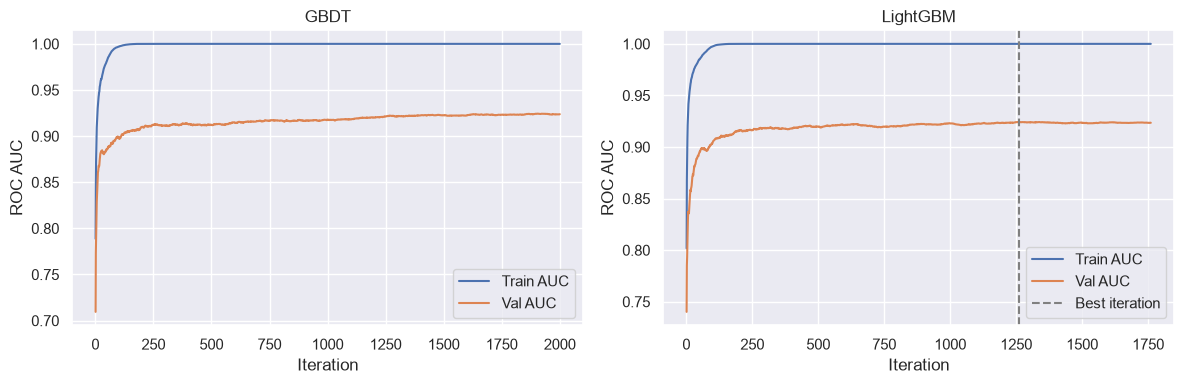

Пайплайн завершён. Предсказания и таблица метрик готовы.


In [56]:
preds_df, metrics_df = run_model_pipeline(
    models, X_train, y_train, X_val, y_val,
    use_cleanlab=False,  # True — сравнить обычную модель и CleanLearning
)

In [ ]:
metrics_df

,Model,Started At,Params,Model File,Cleanlab,Seed,Features,Best Iteration,Train AUC,Val AUC,Fit Time (s)
0,LightGBM,2026-09-20T17:36:56.432406+03:00,"{'boosting_type': 'gbdt', 'class_weight': None...",pipeline_2026-09-20_17-35-57_671129/04_base.jo...,False,42,"[f0000, f0001, f0002, f0003, f0004, f0005, f00...",1260.0,1.000000,0.924311,6.153
1,GBDT,2026-09-20T17:36:32.493269+03:00,"{'ccp_alpha': 0.0, 'criterion': 'deprecated', ...",pipeline_2026-09-20_17-35-57_671129/03_base.jo...,False,42,"[f0000, f0001, f0002, f0003, f0004, f0005, f00...",NaN,1.000000,0.923788,21.357
2,Random Forest,2026-09-20T17:35:57.933904+03:00,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",pipeline_2026-09-20_17-35-57_671129/02_base.jo...,False,42,"[f0000, f0001, f0002, f0003, f0004, f0005, f00...",NaN,0.999730,0.906403,33.954
3,Decision Tree,2026-09-20T17:35:57.672734+03:00,"{'ccp_alpha': 0.0, 'class_weight': None, 'crit...",pipeline_2026-09-20_17-35-57_671129/01_base.jo...,False,42,"[f0000, f0001, f0002, f0003, f0004, f0005, f00...",NaN,0.890544,0.787908,0.252


Лог запуска: /Users/platon/Documents/sbmt_kaggle/logs/pipeline_2026-09-20_17-39-40_225395.json
Пайплайн: 4 моделей | train=(2520, 519), val=(560, 519)

[1/4] Decision Tree
  Вариант: Decision Tree
  Обучение...
  Fit завершён за 0.3 с. Считаю предсказания и AUC...
  Train AUC: 0.89812 | Val AUC: 0.82568
  Извлекаю историю AUC по итерациям...
  Модель готова.
Обученная модель сохранена: logs/pipeline_2026-09-20_17-39-40_225395/01_base.joblib
  Результат сохранён: pipeline_2026-09-20_17-39-40_225395.json

[2/4] Random Forest
  Вариант: Random Forest
  Обучение...
  Fit завершён за 35.3 с. Считаю предсказания и AUC...
  Train AUC: 0.99880 | Val AUC: 0.90908
  Извлекаю историю AUC по итерациям...
  Модель готова.
Обученная модель сохранена: logs/pipeline_2026-09-20_17-39-40_225395/02_base.joblib
  Результат сохранён: pipeline_2026-09-20_17-39-40_225395.json

[3/4] GBDT
  Вариант: GBDT
  Обучение...
  Fit завершён за 21.9 с. Считаю предсказания и AUC...
  Train AUC: 1.00000 | Val AUC: 0.928

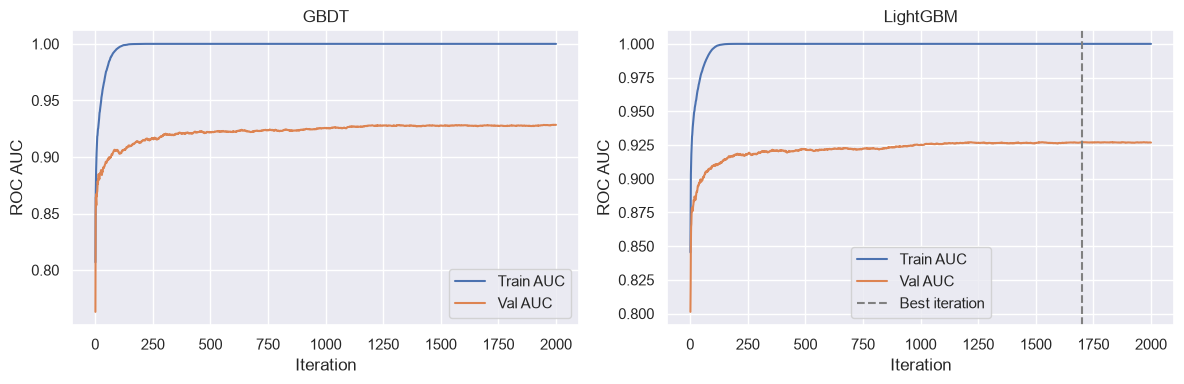

Пайплайн завершён. Предсказания и таблица метрик готовы.


In [ ]:
preds_df_extended, metrics_df_extended = run_model_pipeline(
    models, X_train_extended, y_train, X_val_extended, y_val,
    use_cleanlab=False,  # True — сравнить обычную модель и CleanLearning
)

In [ ]:
metrics_df_extended

,Model,Started At,Params,Model File,Cleanlab,Seed,Features,Best Iteration,Train AUC,Val AUC,Fit Time (s)
0,GBDT,2026-09-20T17:37:39.009882+03:00,"{'ccp_alpha': 0.0, 'criterion': 'deprecated', ...",pipeline_2026-09-20_17-37-02_897172/03_base.jo...,False,42,"[f0000, f0001, f0002, f0003, f0004, f0005, f00...",NaN,1.000000,0.926250,21.726
1,LightGBM,2026-09-20T17:38:03.542318+03:00,"{'boosting_type': 'gbdt', 'class_weight': None...",pipeline_2026-09-20_17-37-02_897172/04_base.jo...,False,42,"[f0000, f0001, f0002, f0003, f0004, f0005, f00...",1437.0,1.000000,0.924617,6.409
2,Random Forest,2026-09-20T17:37:03.179846+03:00,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...",pipeline_2026-09-20_17-37-02_897172/02_base.jo...,False,42,"[f0000, f0001, f0002, f0003, f0004, f0005, f00...",NaN,0.999048,0.908214,35.294
3,Decision Tree,2026-09-20T17:37:02.898012+03:00,"{'ccp_alpha': 0.0, 'class_weight': None, 'crit...",pipeline_2026-09-20_17-37-02_897172/01_base.jo...,False,42,"[f0000, f0001, f0002, f0003, f0004, f0005, f00...",NaN,0.893775,0.855357,0.271


## Пайплайн с 

## Эксперимент: log1p → StandardScaler → RBF SVC

Используем `X_train_extended`, `X_val_extended`, `X_test_extended` из Feature Engineering. SVC — самостоятельная модель, GBDT здесь не участвует.

CV ROC-AUC считаем по `decision_function`. Все преобразования обучаются внутри фолдов. Затем калибруем вероятности на train для `predict_proba` и submission; validation в обучении и калибровке не участвует. Сохраняем весь конвейер, поэтому при загрузке передаём extended-признаки **без ручного log1p и масштабирования**.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.calibration import CalibratedClassifierCV

svc_pipeline = Pipeline([
    ('log1p', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler()),
    ('svc', SVC(C=10, kernel='rbf', gamma='scale')),
])
svc_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name, features in [('train', X_train_extended), ('val', X_val_extended),
                       ('test', X_test_extended)]:
    if not np.isfinite(features.to_numpy()).all() or (features < 0).any().any():
        raise ValueError(f'{name}: для этого эксперимента нужны конечные неотрицательные признаки')
    if list(features.columns) != list(X_train_extended.columns):
        raise ValueError(f'{name}: состав или порядок признаков отличается от train')
print(f'SVC: {X_train_extended.shape[1]} признаков')

SVC: 517 признаков


In [ ]:
svc_cv_scores = cross_val_score(
    svc_pipeline, X_train_extended, y_train,
    cv=svc_cv, scoring='roc_auc', n_jobs=1,
)
print('CV AUC по фолдам:', np.round(svc_cv_scores, 5))
print(f'CV AUC: {svc_cv_scores.mean():.5f} ± {svc_cv_scores.std():.5f}')

CV AUC по фолдам: [0.93662 0.92782 0.92761 0.92503 0.92536]
CV AUC: 0.92849 ± 0.00422


In [ ]:
# Калибруется весь Pipeline: scaler обучается заново внутри каждого фолда.
# ensemble=False: итоговая SVC обучается на всём train.
svc_model = CalibratedClassifierCV(
    estimator=svc_pipeline, method='sigmoid', cv=svc_cv, ensemble=False,
)
svc_started_at = datetime.now().astimezone()
svc_start = time.perf_counter()
svc_model.fit(X_train_extended, y_train)
svc_fit_time = time.perf_counter() - svc_start

svc_train_probs = svc_model.predict_proba(X_train_extended)[:, 1]
svc_val_probs = svc_model.predict_proba(X_val_extended)[:, 1]
svc_metrics = pd.DataFrame([{
    'Model': 'log1p + StandardScaler + RBF SVC (extended)',
    'CV AUC (decision_function)': svc_cv_scores.mean(),
    'CV STD': svc_cv_scores.std(),
    'Train AUC': roc_auc_score(y_train, svc_train_probs),
    'Val AUC': roc_auc_score(y_val, svc_val_probs),
    'Fit + Calibration Time (s)': round(svc_fit_time, 3),
}])

svc_run_dir = LOG_DIR / f'svc_{svc_started_at:%Y-%m-%d_%H-%M-%S_%f}'
svc_model_path = save_model(svc_model, svc_run_dir / 'model.joblib')
svc_log = {
    'run_started_at': svc_started_at.isoformat(),
    'feature_columns': list(X_train_extended.columns),
    'params': {'C': 10, 'kernel': 'rbf', 'gamma': 'scale'},
    'preprocessing': ['log1p', 'StandardScaler'],
    'calibration': {'method': 'sigmoid', 'ensemble': False, 'folds': 5},
    'seed': SEED,
    'cv_scores': svc_cv_scores.tolist(),
    'results': [{
        **json.loads(svc_metrics.to_json(orient='records'))[0],
        'Model File': 'model.joblib',
    }],
}
(svc_run_dir / 'results.json').write_text(
    json.dumps(svc_log, ensure_ascii=False, indent=2), encoding='utf-8',
)
pd.DataFrame({
    'row_id': val_df['row_id'], 'target': y_val, 'prediction': svc_val_probs,
}).to_csv(svc_run_dir / 'validation_predictions.csv', index=False)
print(f'Результаты: {svc_run_dir.resolve()}')
display(svc_metrics)

Обученная модель сохранена: logs/svc_2026-09-20_17-38-12_137077/model.joblib
Результаты: /Users/platon/Documents/sbmt_kaggle/logs/svc_2026-09-20_17-38-12_137077


,Model,CV AUC (decision_function),CV STD,Train AUC,Val AUC,Fit + Calibration Time (s)
0,log1p + StandardScaler + RBF SVC (extended),0.928486,0.004221,1.0,0.946888,2.223


In [ ]:
# Выполни эти строки, когда понадобится файл для Kaggle:
# submission_svc = save_submission(
#     svc_model, X_test_extended, test_df['row_id'], sample_submission,
#     OUTPUT_DIR / 'submission_svc_extended.csv',
# )

# После перезапуска ядра можно загрузить весь обученный конвейер:
# svc_model = load_model(svc_run_dir / 'results.json', svc_log['results'][0]['Model'])

## Поиск параметров
Включается флагом `RUN_SEARCH` в настройках.
CV здесь — дополнительная диагностика. Основное сравнение моделей по условиям соревнования — на supplied validation, отделённом по скрытым сущностям.

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
param_grids = {
    'Random Forest': {
        'n_estimators': [300, 500, 800, 1000, 1100, 1200, 1300, 1400, 1500, 1700, 1800, 2000],
        'max_depth': [5, 10, 15],
        'min_samples_split': [5, 10, 20, 50],
        'min_samples_leaf': [5, 10, 20],
        'max_features': ['sqrt', 'log2', 0.3, 0.5],
    },

    'GBDT': {
        'n_estimators': [2000, 2200, 2500],
        'learning_rate': [0.05, 0.1, 0.15, 0.2],
        'max_depth': [3, 4, 5],
        'min_samples_split': [5],
        'min_samples_leaf': [10, 20, 30],
        'max_features': ['sqrt', 0.1, 0.3, 0.5],
        'subsample': [0.6, 0.8],
    },
    'LightGBM': {
        'n_estimators': [1000, 1500, 2000, 2500],
        'learning_rate': [0.02, 0.03, 0.05],
        'max_depth': [4, 5, 6, 7],
        'num_leaves': [7, 15, 16],
        'min_child_samples': [20, 30, 50, 80],
        'subsample': [0.6, 0.7, 0.8],
        'colsample_bytree': [0.5, 0.7, 0.9],
        'reg_alpha': [0.0, 0.01, 0.1],
        'reg_lambda': [0.0, 0.01, 0.1, 1.0],
    },
}

In [ ]:
preds_df_search = metrics_df_search = None
if RUN_SEARCH:
    preds_df_search, metrics_df_search = run_model_pipeline_search(
        models, param_grids, X_train, y_train, X_val, y_val,
        n_iter=30, cv=cv, scoring='roc_auc', plot_curves=True,
        verbose=10, n_jobs=-1,
    )
    display(metrics_df_search)

## Эксперименты с CleanLearning
Включаются флагом `RUN_CLEANLAB` в настройках.

In [ ]:
if RUN_CLEANLAB:
    model = RandomForestClassifier(n_estimators=200, max_depth=5, min_samples_split=50, min_samples_leaf=20, random_state=SEED, n_jobs=-1)
    cl = cleanlab.classification.CleanLearning(model, seed=SEED, verbose=True)
    cl.fit(X_train, y_train)
    model = clone(model)
    model.fit(X_train, y_train)

    # issues = cl.get_label_issues()
    # print(issues['is_label_issue'].sum())
    print("Val AUC (cleaned):", roc_auc_score(y_val, cl.predict_proba(X_val)[:, 1]))
    print('Val AUC (model):', roc_auc_score(y_val, model.predict_proba(X_val)[:, 1]))
    print('model params:', model.get_params())

In [ ]:
# True — сравнить обычную модель и CleanLearning.
if RUN_CLEANLAB:
    models_clean = {'LightGBM': models['LightGBM']}
    preds_df_clean, metrics_df_clean = run_model_pipeline(
        models_clean, X_train, y_train, X_val, y_val, use_cleanlab=True,
    )
    display(metrics_df_clean)

## Предсказания сохранённой модели
По умолчанию сохраняется submission GBDT из текущего extended-запуска. Для загрузки исторической модели укажи JSON_PATH. В этом режиме достаточно настройки, подготовки данных и функций сохранения/загрузки.

In [ ]:
# По умолчанию используем GBDT из текущего запуска на extended-признаках.
# Для отдельной загрузки старого запуска явно укажи JSON_PATH.
JSON_PATH = None  # Например: LOG_DIR / 'pipeline_2026-09-19_20-51-16_279271.json'
MODEL_NAME = 'GBDT'  # Например: 'Random Forest + Cleanlab'
SUBMISSION_PATH = OUTPUT_DIR / 'submission_GBDT_extended.csv'

if JSON_PATH is None:
    model_info = metrics_df_extended.loc[metrics_df_extended['Model'] == MODEL_NAME].iloc[0]
    selected_model = joblib.load(LOG_DIR / model_info['Model File'])
else:
    selected_model = load_model(JSON_PATH, MODEL_NAME)
submission = save_submission(
    selected_model, X_test_extended, test_df['row_id'], sample_submission, SUBMISSION_PATH,
)
display(submission.head())

Предсказываю для 1116 строк...
Сохранено: /Users/platon/Documents/sbmt_kaggle/submission_GBDT_extended.csv | (1116, 2)


,row_id,target
0,row_46ad1afad8562239f79c,1.000000e+00
1,row_b42ade9cd57b8d919acb,9.999992e-01
2,row_c951cd5e197b6b4e8b83,1.400815e-02
3,row_a54b3423760d599416ce,1.239062e-07
4,row_a87c87cc47690e2a303f,1.000000e+00
